In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Cardiotocographic.csv')

In [ ]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [ ]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [ ]:
df.shape

(2126, 14)

How many rows contain at least one missing value?

In [ ]:
df[df.isnull().any(axis=1)].shape

(21, 14)

In [ ]:
df.isnull().any(axis=1).sum()

np.int64(21)

Before filling or dropping:

Count missing values per column

Count affected rows

Calculate percentage of affected rows

In [ ]:
missing_rows = df.isnull().any(axis=1).sum()

print(missing_rows)
print((missing_rows/len(df))*100) # here lenn(df) gives no.of rows 2126

0
0.0


Less than 5% → usually drop rows

More than 5–10% → consider imputation (mean/median/mode)

The dataset contains 2126 records. Missing value analysis showed that only 21 records contained incomplete information, representing approximately 1% of the dataset. Since the missing data percentage is very small, these records can be safely removed without significantly affecting the analysis.

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2105 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2105 non-null   float64
 2   FM        2105 non-null   float64
 3   UC        2105 non-null   float64
 4   DL        2105 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2105 non-null   float64
 8   MSTV      2105 non-null   float64
 9   ALTV      2105 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 246.7 KB


In [ ]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003202,0.009963,0.004388,0.001892,0.000003,0.000175,46.996929,1.361006,10.353647,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004324,0.067870,0.003350,0.003348,0.000142,0.000840,18.847737,1.173164,21.282102,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001838,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001631,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002554,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


After data cleaning, the dataset contained 2105 observations and 14 numerical variables. No missing values were present, indicating that the dataset was ready for exploratory analysis.

all are decribed based on the LB feature in the dataset

The distribution of fetal heart rate appears balanced because the mean and median are nearly identical

as the mean and the median has less difference in them

in the terms of std

Most fetal heart rate values are reasonably close to the average, with moderate variation among observations.

in terms of min and max

The dataset contains some unusually low and high fetal heart rate observations, suggesting potential outliers or abnormal fetal conditions.


based on the quartiles

Half of the fetal heart rate observations lie between 126 BPM and 140 BPM.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

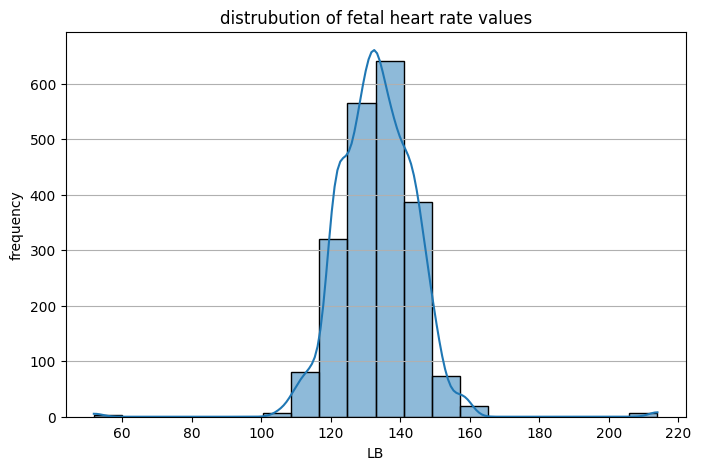

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x = 'LB',
    kde = True,
    bins = 20
)
plt.title('distrubution of fetal heart rate values')
plt.xlabel('LB')
plt.ylabel('frequency')

plt.grid(axis= 'y')


In [ ]:
columns= [
    'ASTV',
    'MSTV',
    'ALTV',
    'MLTV',
    'Width'
]

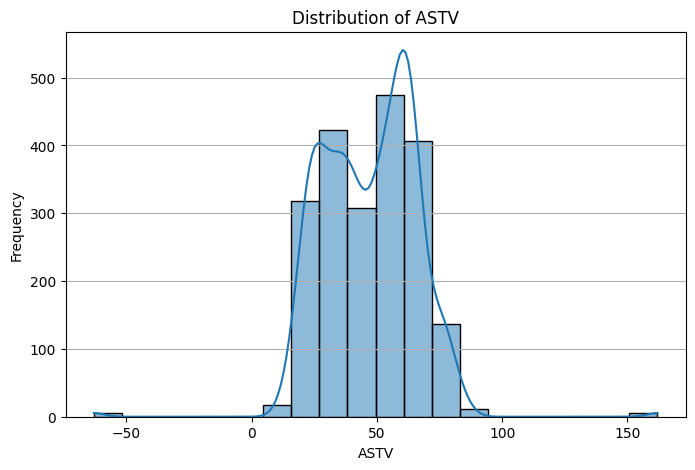

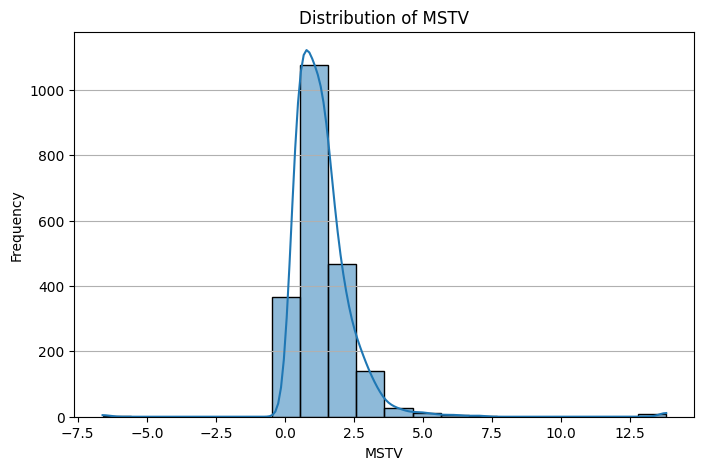

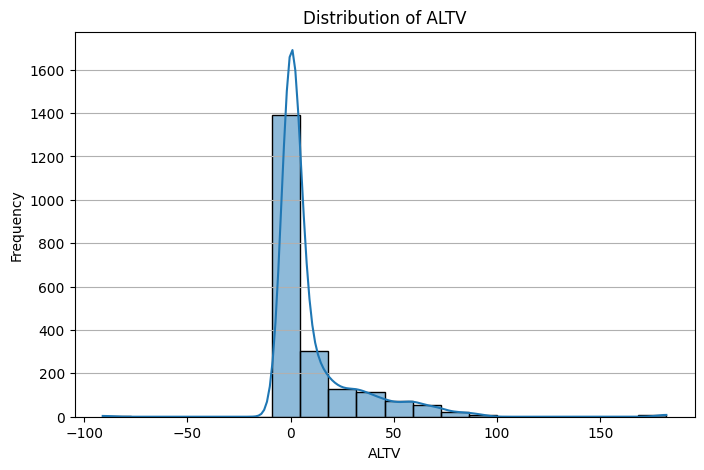

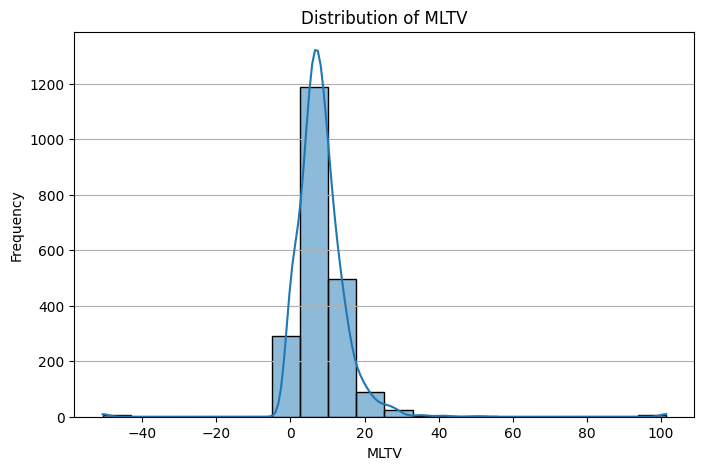

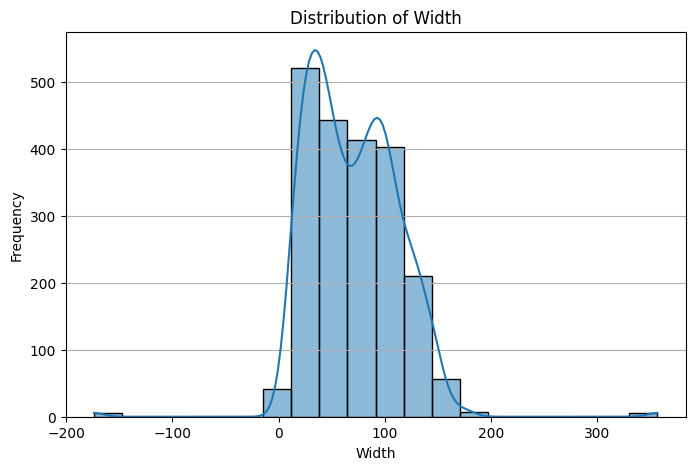

In [ ]:
for col in columns:
    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=20
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.grid(axis='y')

    plt.show()

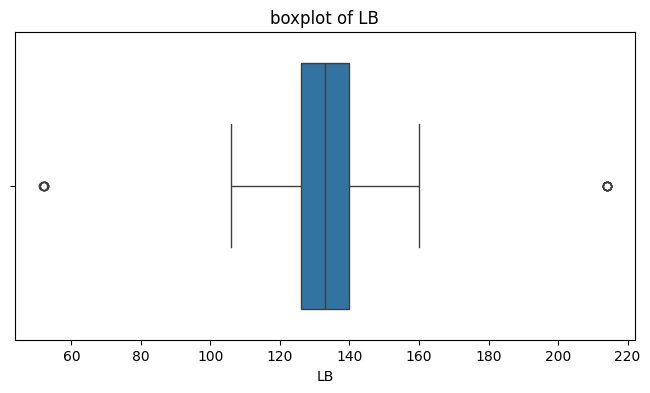

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data = df,
    x = 'LB'
)
plt.title('boxplot of LB')
plt.xlabel('LB')
plt.show()

LB demonstrates a relatively symmetric distribution with limited variability and only a few extreme observations. Most fetal heart rate values are concentrated around the median.

In [ ]:
bp_columns = [
    'ASTV',
    'MSTV',
    'ALTV',
    'MLTV',
    'Width'
]

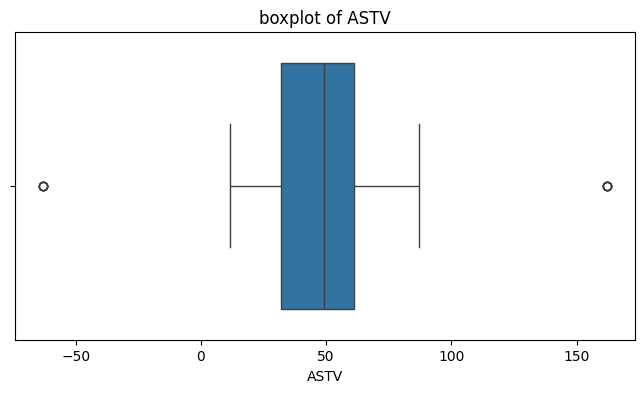

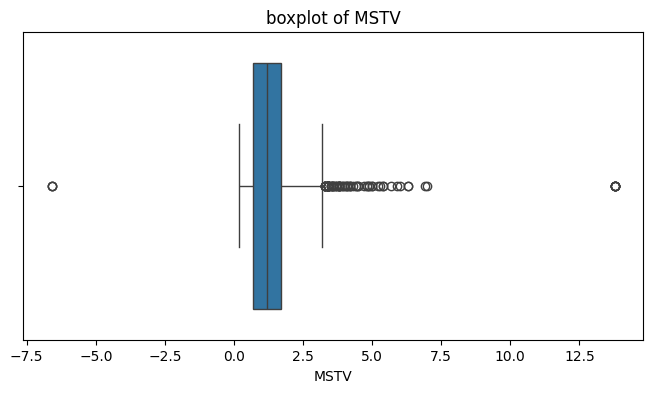

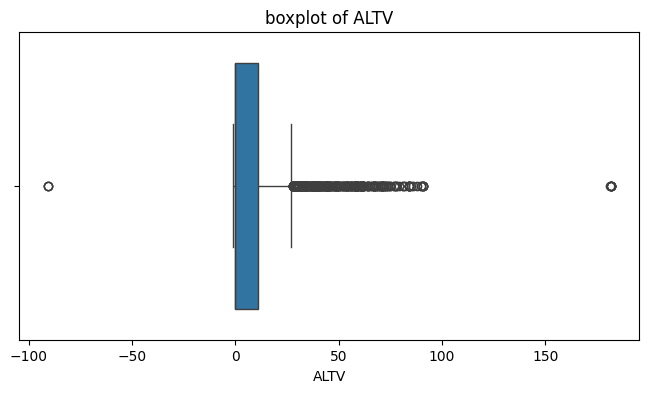

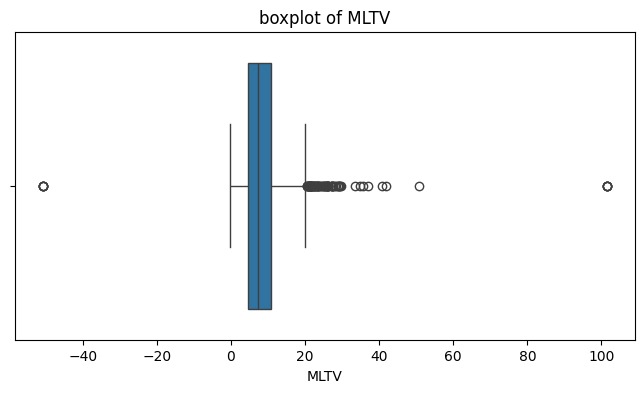

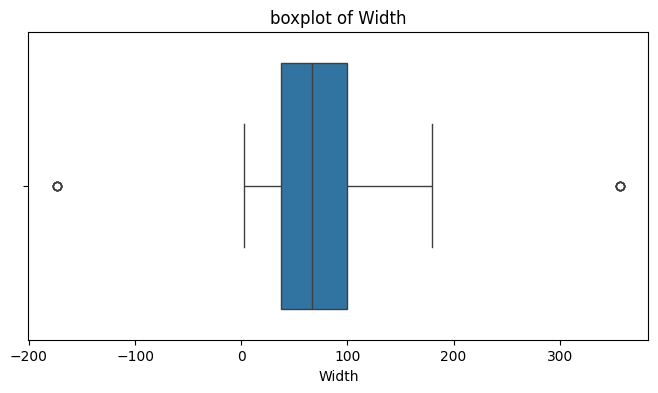

In [ ]:
for col in bp_columns :
  plt.figure(figsize=(8,4))
  sns.boxplot(
      data = df,
      x = col
  )
  plt.title(f'boxplot of {col}')
  plt.xlabel(col)
  plt.show()

The MSTV variable is positively skewed, with most observations concentrated at lower values. Several high-value outliers are present, indicating unusual observations that may require further investigation

ALTV exhibits a strong positive skew with a substantial number of upper-end outliers. Most observations are concentrated at lower values, while a few records have exceptionally high values.

MLTV is positively skewed with several extreme observations. The majority of values are clustered within a narrow range, while a few unusually large values increase the overall spread of the data.

Width is relatively symmetric compared to the previous variables. Although a few extreme outliers are present, most observations are distributed evenly around the median.


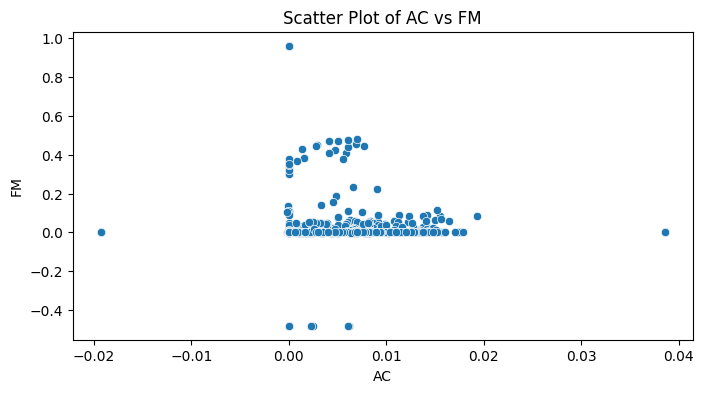

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data = df ,
    x='AC',
    y='FM'
)
plt.title('Scatter Plot of AC vs FM')
plt.xlabel('AC')
plt.ylabel('FM')

plt.show()

The scatter plot of AC and FM shows no significant linear relationship. Most observations are concentrated around FM = 0, indicating that changes in AC have little observable effect on FM

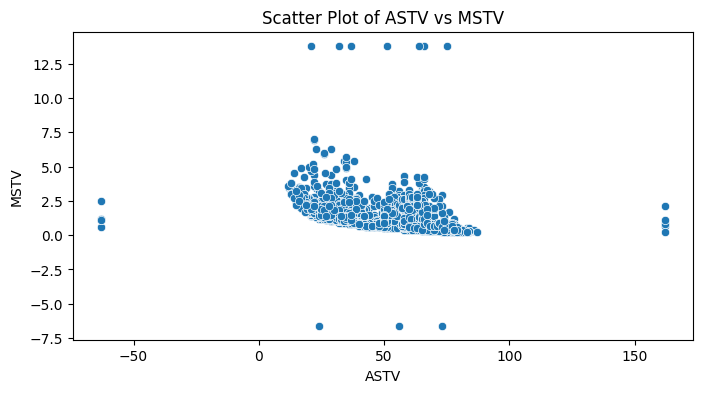

In [ ]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x='ASTV',
    y='MSTV'
)

plt.title('Scatter Plot of ASTV vs MSTV')
plt.xlabel('ASTV')
plt.ylabel('MSTV')

plt.show()

The scatter plot indicates a weak to moderate negative relationship between ASTV and MSTV. Higher ASTV values are generally associated with lower MSTV values, although the relationship is not perfectly linear.

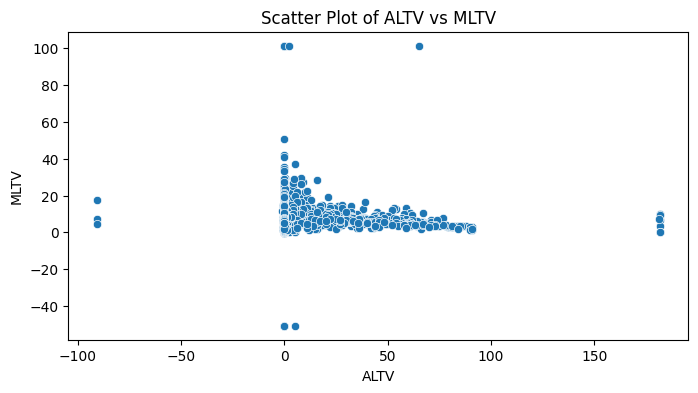

In [ ]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x='ALTV',
    y='MLTV'
)

plt.title('Scatter Plot of ALTV vs MLTV')
plt.xlabel('ALTV')
plt.ylabel('MLTV')

plt.show()

The scatter plot of ALTV and MLTV does not show a strong linear relationship. The points are widely dispersed with several outliers. This suggests that changes in ALTV do not consistently correspond to changes in MLTV.

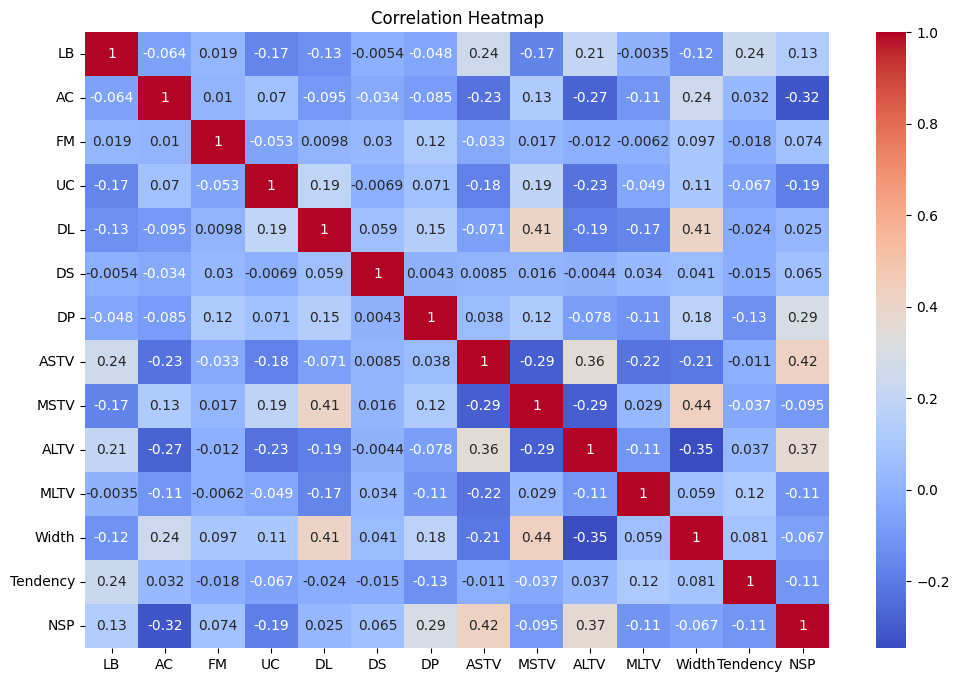

In [ ]:
# heat map for all the data which code includes df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

both the heat maps are same but the code shows the difference in how all data shown in the heatmap and only numerical columns are shown in the heatmap

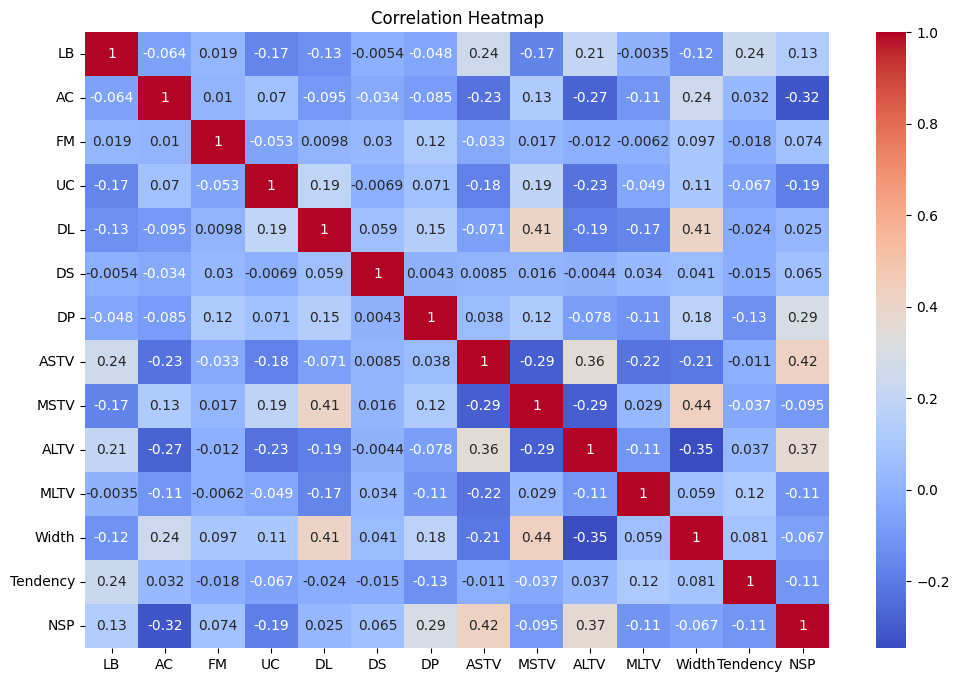

In [ ]:
# heat map for all the data which code includes df.corr() for numeric_values categories
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

ASTV and NSP show a moderate positive relationship. Higher ASTV values are generally associated with higher NSP values

MSTV and Width exhibit a moderate positive correlation, indicating that increases in MSTV tend to be associated with increases in Width.

DL and Width demonstrate a moderate positive relationship, suggesting that higher DL values are often accompanied by larger Width values.

ALTV has a moderate positive association with NSP, indicating that NSP tends to increase as ALTV increases.

ASTV and ALTV show a moderate positive relationship, suggesting that both variables tend to increase together.

ALTV and Width exhibit a moderate negative correlation. Higher ALTV values are generally associated with lower Width values.

AC demonstrates a moderate negative relationship with NSP, indicating that NSP tends to decrease as AC increases.

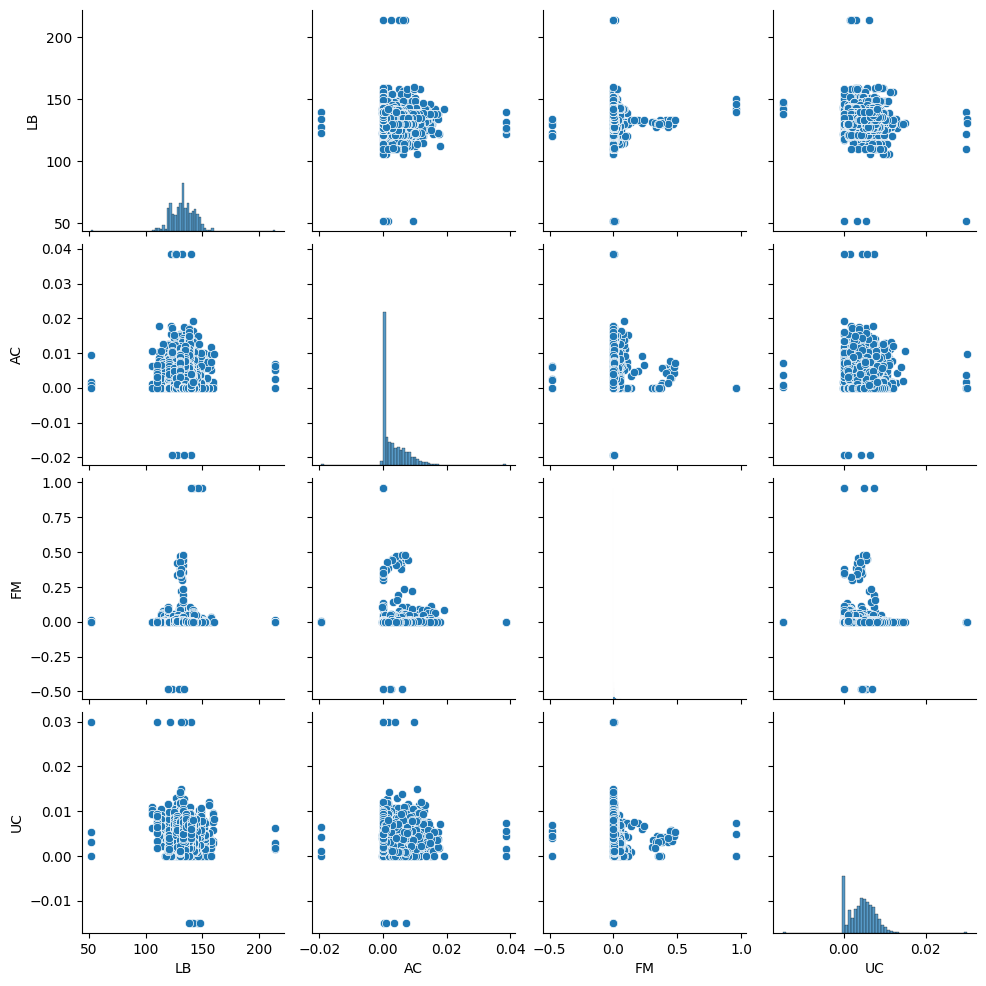

In [ ]:
sns.pairplot(
    df[['LB','AC','FM','UC']],
    diag_kind='hist'

)

plt.show()

Pair Plot

Show all relationships at once

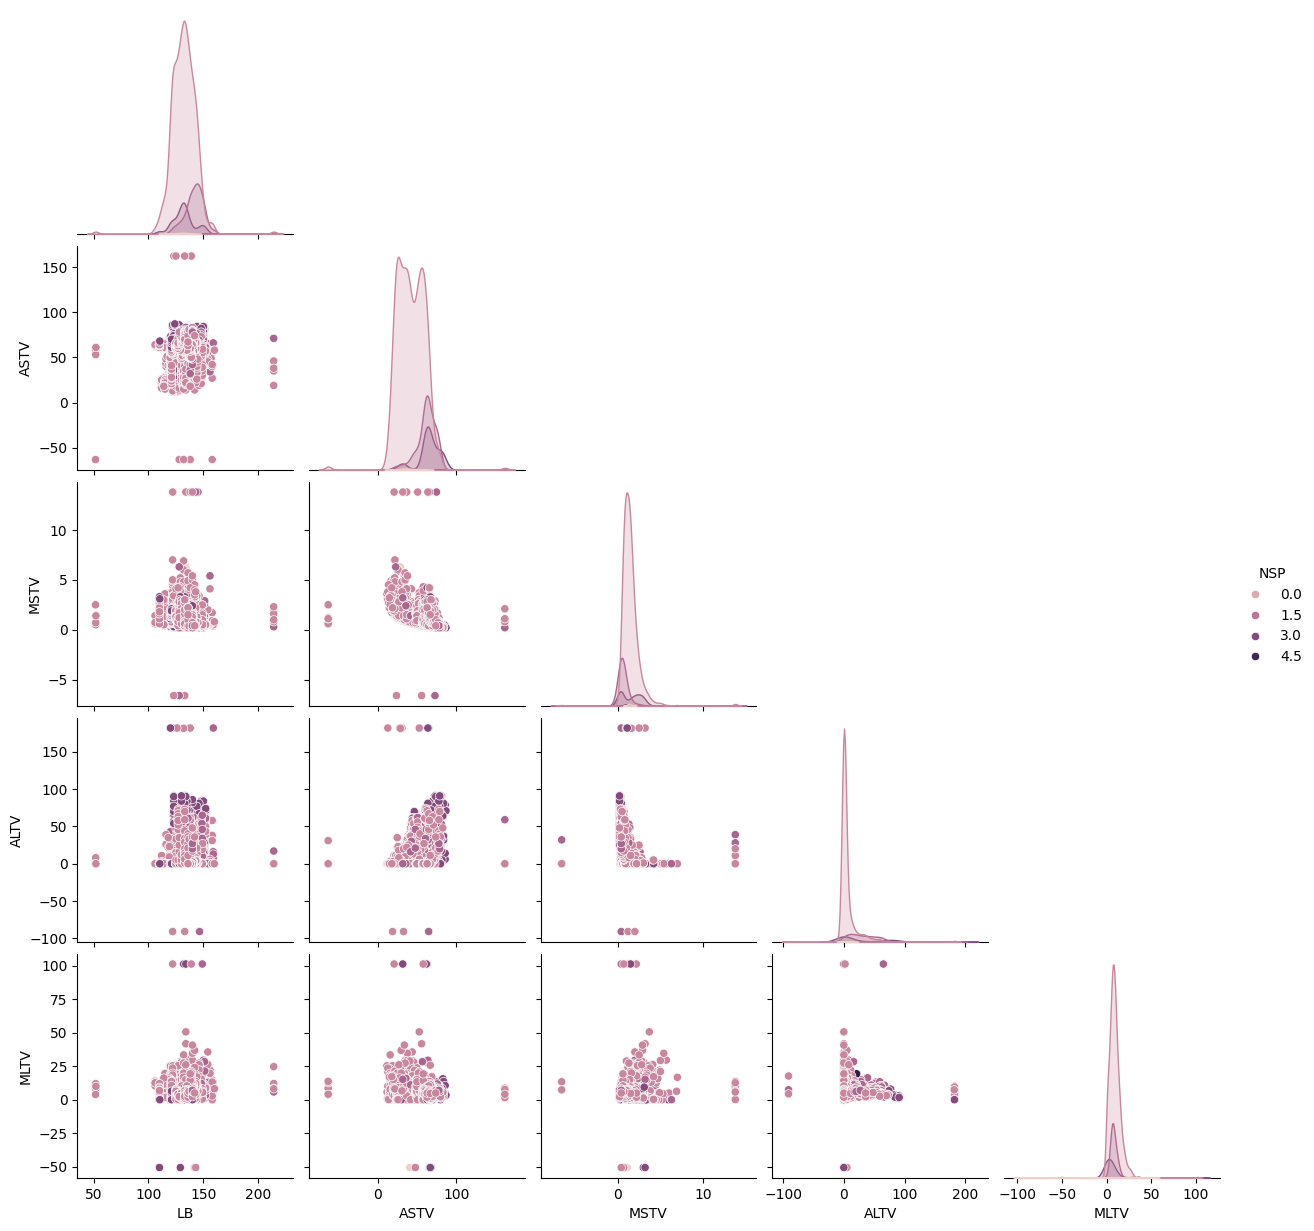

In [ ]:
sns.pairplot(
    df[['LB','ASTV','MSTV','ALTV','MLTV','NSP']],
    hue='NSP',
    corner=True
)

Count Plot

How many records belong to each category?

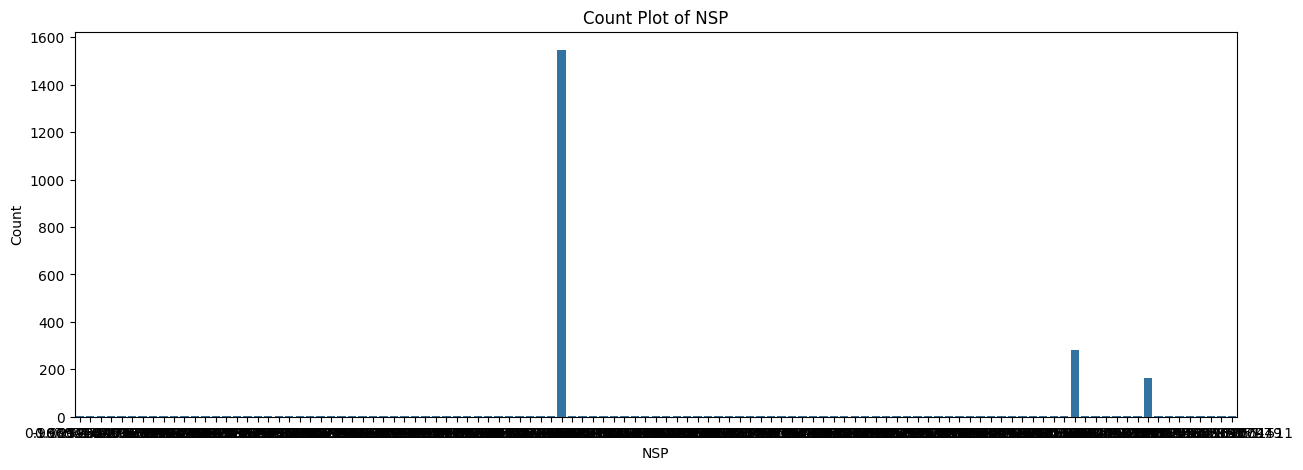

In [ ]:
plt.figure(figsize=(15,5))

sns.countplot(
    data=df,
    x='NSP',
)

plt.title('Count Plot of NSP')
plt.xlabel('NSP')
plt.ylabel('Count')
plt.show()

In [ ]:
df['NSP'].value_counts().sort_index()

,count
NSP,
-1.025988,1
-1.000000,5
0.967075,1
0.969447,1
0.972305,1
...,...
3.015185,1
3.019152,1
3.020038,1


the column has too many unique values to be treated as a category.

that is why we cant get the x-axsis completely showing categories

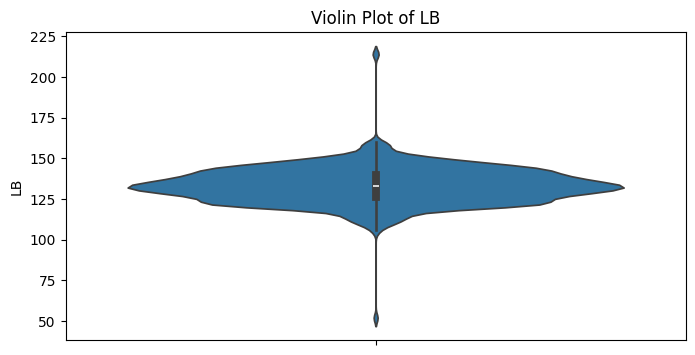

In [ ]:
plt.figure(figsize=(8,4))

sns.violinplot(
    y=df['LB']
)

plt.title('Violin Plot of LB')

plt.show()

Half of the fetal heart rate observations lie between 126 BPM and 140 BPM.

"Most fetal heart rates are normal and concentrated around 130–140 BPM, while only a small number of observations show extremely low or high values."

#### Summary of Findings and Recommendations



The Cardiotocographic dataset was analyzed to understand the patterns and characteristics of fetal health indicators. After handling the missing values, the dataset was found to be clean and suitable for analysis. The average baseline fetal heart rate was around 133 BPM, with most observations concentrated between 126 and 140 BPM.



Visualizations revealed the presence of a few outliers and showed that several variables have meaningful relationships with each other. Correlation analysis indicated that some fetal movement and variability-related features are associated and may be useful for understanding fetal health conditions.



For further analysis, predictive modeling techniques can be applied to classify fetal health conditions and identify important factors influencing fetal well-being. Additional investigation of outliers may also provide insights into abnormal fetal conditions.
